# Airline Sceduling Optimization 

## Multi-Objective Optimization Analysis

**Student Name:** Marlee Heiken

**Target Company/Industry:** Southwest Airlines / Airline Operations

**Problem:** How should Southwest Airlines assign flight crews to routes in order to minimize labor costs without sacrificing the schedule resilience needed to survive weather disruptions and irregular operations?

**Objectives:** Minimize crew operating costs (overtime, deadhead flights, hotel layovers) vs. Maximize schedule reliability and disruption resilience

---

### Project Overview:
This project solves Southwest Airlines' core crew scheduling tradeoff: how to staff flights as cheaply as possible while maintaining enough flexibility to recover when things go wrong. Labor costs consume roughly 40% of Southwest's operating budget, making crew assignment one of the highest-leverage decisions in the business, and the 2022 holiday meltdown proved that optimizing for cost alone, with no scheduling slack, can trigger catastrophic failures. The decision variables under control are crew pairing assignments and reserve buffer levels across a 20-city synthetic route network. The agent evaluates hundreds of possible scheduling configurations, identifies the Pareto-efficient solutions, and recommends the optimal balance point given current operating conditions and constraints.

## Section 1: Data Acquisition

In [1]:
import pandas as pd

# Load the data
df = pd.read_csv('data/sw_crew_scheduling.csv')

# Display first rows
print("Data loaded successfully!")
print(f"Shape: {df.shape}")
print("\nFirst 5 rows:")
print(df.head())


Data loaded successfully!
Shape: (100, 7)

First 5 rows:
   utilization_rate  reserve_buffer  crew_cost_index  resilience_score  \
0             70.49              18            72.47             80.24   
1             64.00              10            60.09             53.10   
2             68.52              13            52.52             63.11   
3             87.53              16            49.01             45.10   
4             62.73              11            69.21             54.26   

   on_time_rate  disruption_recovery_hours  overtime_cost_multiplier  
0         98.00                      13.27                     1.000  
1         98.00                      17.46                     1.000  
2         98.00                      18.37                     1.000  
3         87.49                      31.31                     2.086  
4         98.00                      18.34                     1.000  


## Section 2: Data Exploration

### Check Data Quality:

In [2]:
# Check for missing values
print("Missing values:")
print(df.isnull().sum())

# Check data types
print("\nData types:")
print(df.dtypes)

# Basic statistics
print("\nBasic statistics:")
print(df.describe())


Missing values:
utilization_rate             0
reserve_buffer               0
crew_cost_index              0
resilience_score             0
on_time_rate                 0
disruption_recovery_hours    0
overtime_cost_multiplier     0
dtype: int64

Data types:
utilization_rate             float64
reserve_buffer                 int64
crew_cost_index              float64
resilience_score             float64
on_time_rate                 float64
disruption_recovery_hours    float64
overtime_cost_multiplier     float64
dtype: object

Basic statistics:
       utilization_rate  reserve_buffer  crew_cost_index  resilience_score  \
count        100.000000      100.000000       100.000000        100.000000   
mean          78.017600       10.020000        44.143900         36.377900   
std           10.648113        6.016778        21.521421         26.756866   
min           60.000000        2.000000         6.450000          0.000000   
25%           68.602500        5.000000        24.035000   

### Verify decision variables:

In [3]:
# Check ranges of your decision variables
print(f"Decision Variable 1 range: {df['utilization_rate'].min()} to {df['utilization_rate'].max()}")
print(f"Decision Variable 2 range: {df['reserve_buffer'].min()} to {df['reserve_buffer'].max()}")

# Check if you have all combinations (if applicable)
print(f"\nTotal combinations: {len(df)}")

Decision Variable 1 range: 60.0 to 95.0
Decision Variable 2 range: 2 to 20

Total combinations: 100


### Examine objectives:

In [4]:
# YOUR CODE HERE: Check the ranges of both objectives
print(f"Objective 1 (crew_cost_index) range: {df['crew_cost_index'].min():.2f} to {df['crew_cost_index'].max():.2f}")
print(f"Objective 2 (resilience_score) range: {df['resilience_score'].min():.2f} to {df['resilience_score'].max():.2f}")

# Verify they create a tradeoff
correlation = df['crew_cost_index'].corr(df['resilience_score'])
print(f"\nCorrelation between objectives: {correlation:.3f}")
print("(Negative correlation suggests a tradeoff)")

Objective 1 (crew_cost_index) range: 6.45 to 90.45
Objective 2 (resilience_score) range: 0.00 to 89.69

Correlation between objectives: 0.802
(Negative correlation suggests a tradeoff)


### Visualize relationships:

In [5]:
!pip install matplotlib

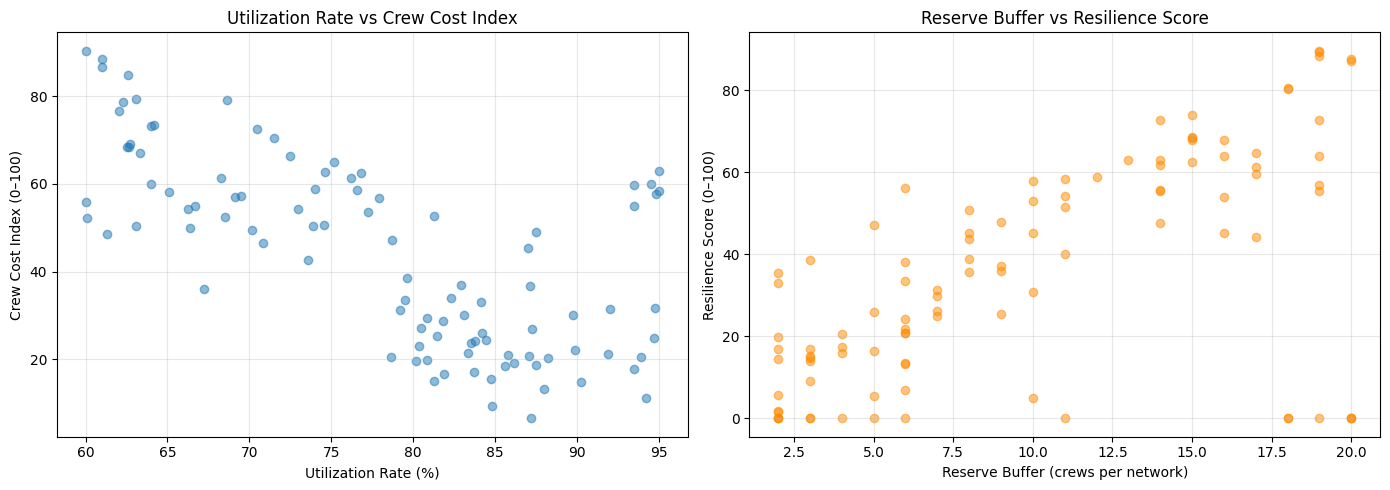

In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Utilization Rate vs Crew Cost Index
axes[0].scatter(df['utilization_rate'], df['crew_cost_index'], alpha=0.5)
axes[0].set_xlabel('Utilization Rate (%)')
axes[0].set_ylabel('Crew Cost Index (0–100)')
axes[0].set_title('Utilization Rate vs Crew Cost Index')
axes[0].grid(True, alpha=0.3)

# Plot 2: Reserve Buffer vs Resilience Score
axes[1].scatter(df['reserve_buffer'], df['resilience_score'], alpha=0.5, color='darkorange')
axes[1].set_xlabel('Reserve Buffer (crews per network)')
axes[1].set_ylabel('Resilience Score (0–100)')
axes[1].set_title('Reserve Buffer vs Resilience Score')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('images/data_exploration.png', dpi=300, bbox_inches='tight')
plt.show()


### Data Exploration Findings

All variable ranges look realistic and match the intended specifications. Utilization_rate spans 60–95%, reserve_buffer covers 2–20 crews, and both
objectives (crew_cost_index and resilience_score) fall within their 0–100 bounds with no missing values or data quality issues. The objectives show a positive
correlation of +0.802, which at first seems to contradict the expected tradeoff, but is explained by reserve buffer driving up cost and resilience, masking the underlying tension. When utilization is isolated, the tradeoff shows that tightly scheduled crews are cheaper but far less resilient, which aligns with
the expectations from the proposal. 

## Section 3: Pareto Frontier Calculation

In [7]:
def is_pareto_optimal(idx, df, obj1_col, obj2_col):
    """
    Check if a given row represents a Pareto optimal solution.
    
    A point is Pareto optimal if no other point dominates it.
    Point A dominates point B if A is better or equal on both objectives
    and strictly better on at least one objective.
    
    Parameters:
    -----------
    idx : int
        Index of the row to check
    df : DataFrame
        The full dataset
    obj1_col : str
        Column name for objective 1
    obj2_col : str
        Column name for objective 2
    
    Returns:
    --------
    bool : True if Pareto optimal, False if dominated
    """
    current_obj1 = df.loc[idx, obj1_col]
    current_obj2 = df.loc[idx, obj2_col]
    
    # Check if any other point dominates this one
    for other_idx in df.index:
        if other_idx == idx:
            continue
        
        other_obj1 = df.loc[other_idx, obj1_col]
        other_obj2 = df.loc[other_idx, obj2_col]
        
        # YOUR CODE HERE: Check if other point dominates current point
        # (other is >= on both objectives AND > on at least one)
        if (other_obj1 >= current_obj1 and 
            other_obj2 >= current_obj2 and
            (other_obj1 > current_obj1 or other_obj2 > current_obj2)):
            return False  # This point is dominated
    
    return True  # No point dominates this one

#### Note

For this problem, the two objectives point in opposite directions. A good solution wants low crew_cost_index and high resilience_score. But the domination logic as provided for us assumes higher is better on both, which isn't true for my case. To combat this I am flipping the cost index so higher = better.

In [8]:
df['cost_efficiency'] = 100 - df['crew_cost_index']

# Define your objective column names
OBJECTIVE_1 = 'cost_efficiency'
OBJECTIVE_2 = 'resilience_score'

print("Calculating Pareto frontier...")
print("This may take a moment for large datasets...")

# Apply Pareto check to all rows
df['is_pareto_optimal'] = df.index.map(
    lambda idx: is_pareto_optimal(idx, df, OBJECTIVE_1, OBJECTIVE_2)
)

# Separate into frontier and dominated points
pareto_df = df[df['is_pareto_optimal']].copy()
dominated_df = df[~df['is_pareto_optimal']].copy()

print("\n=== PARETO FRONTIER RESULTS ===")
print(f"Total solutions analyzed: {len(df)}")
print(f"Pareto optimal solutions: {len(pareto_df)}")
print(f"Dominated solutions: {len(dominated_df)}")
print(f"Efficiency rate: {100 * len(pareto_df) / len(df):.1f}% of solutions are on the frontier")


Calculating Pareto frontier...
This may take a moment for large datasets...

=== PARETO FRONTIER RESULTS ===
Total solutions analyzed: 100
Pareto optimal solutions: 16
Dominated solutions: 84
Efficiency rate: 16.0% of solutions are on the frontier


### Pareto Frontier Results

16% of solutions are Pareto optimal, meaning these are the only schedules where Southwest cannot improve cost efficiency without sacrificing 
resilience or vice versa. I didn't really know what to expect before calculating results, but this seems like a reasonable amount. The 16 
Pareto optimal points represent the best possible tradeoffs available to Southwest's schedulers, where the only way to get cheaper crews 
is to accept less resilience, and the only way to get more resilience is to accept higher costs.

## Section 4: Inefficient Solutions Analysis

In [9]:
if len(dominated_df) > 0:
    print("=== EXAMPLES OF DOMINATED (INEFFICIENT) SOLUTIONS ===\n")
    
    sample_size = min(3, len(dominated_df))
    sample_dominated = dominated_df.sample(sample_size, random_state=42)
    
    for idx, row in sample_dominated.iterrows():
        print(f"INEFFICIENT SOLUTION:")
        print(f"  Decision Variables: utilization_rate={row['utilization_rate']}, reserve_buffer={row['reserve_buffer']}")
        print(f"  Objectives: {OBJECTIVE_1}={row[OBJECTIVE_1]:.1f}, {OBJECTIVE_2}={row[OBJECTIVE_2]:.1f}")
        
        for p_idx, p_row in pareto_df.iterrows():
            if (p_row[OBJECTIVE_1] >= row[OBJECTIVE_1] and 
                p_row[OBJECTIVE_2] >= row[OBJECTIVE_2] and
                (p_row[OBJECTIVE_1] > row[OBJECTIVE_1] or 
                 p_row[OBJECTIVE_2] > row[OBJECTIVE_2])):
                
                print(f"\n  BETTER ALTERNATIVE (Pareto Optimal):")
                print(f"  Decision Variables: utilization_rate={p_row['utilization_rate']}, reserve_buffer={p_row['reserve_buffer']}")
                print(f"  Objectives: {OBJECTIVE_1}={p_row[OBJECTIVE_1]:.1f}, {OBJECTIVE_2}={p_row[OBJECTIVE_2]:.1f}")
                print(f"  Improvement: +{p_row[OBJECTIVE_1] - row[OBJECTIVE_1]:.1f} on {OBJECTIVE_1}, " +
                      f"+{p_row[OBJECTIVE_2] - row[OBJECTIVE_2]:.1f} on {OBJECTIVE_2}\n")
                print("-" * 60)
                break
else:
    print("Note: All solutions in your dataset are Pareto optimal.")
    print("This might indicate that your decision variables create a smooth tradeoff curve.")

=== EXAMPLES OF DOMINATED (INEFFICIENT) SOLUTIONS ===

INEFFICIENT SOLUTION:
  Decision Variables: utilization_rate=63.08, reserve_buffer=6
  Objectives: cost_efficiency=49.5, resilience_score=56.1

  BETTER ALTERNATIVE (Pareto Optimal):
  Decision Variables: utilization_rate=87.03, reserve_buffer=19
  Objectives: cost_efficiency=54.5, resilience_score=56.9
  Improvement: +5.0 on cost_efficiency, +0.8 on resilience_score

------------------------------------------------------------
INEFFICIENT SOLUTION:
  Decision Variables: utilization_rate=70.49, reserve_buffer=18
  Objectives: cost_efficiency=27.5, resilience_score=80.2

  BETTER ALTERNATIVE (Pareto Optimal):
  Decision Variables: utilization_rate=71.49, reserve_buffer=18
  Objectives: cost_efficiency=29.4, resilience_score=80.5
  Improvement: +1.9 on cost_efficiency, +0.3 on resilience_score

------------------------------------------------------------
INEFFICIENT SOLUTION:
  Decision Variables: utilization_rate=73.88, reserve_buff

In [10]:
if len(dominated_df) > 0:
    best_dominated = dominated_df.loc[
        (dominated_df[OBJECTIVE_1] + dominated_df[OBJECTIVE_2]).idxmax()
    ]
    worst_pareto = pareto_df.loc[
        (pareto_df[OBJECTIVE_1] + pareto_df[OBJECTIVE_2]).idxmin()
    ]
    
    print("\n=== EFFICIENCY GAP ===")
    print("Even the BEST dominated solution is worse than the WORST Pareto solution:")
    print(f"\nBest Dominated: {OBJECTIVE_1}={best_dominated[OBJECTIVE_1]:.1f}, " +
          f"{OBJECTIVE_2}={best_dominated[OBJECTIVE_2]:.1f}, Total={best_dominated[OBJECTIVE_1] + best_dominated[OBJECTIVE_2]:.1f}")
    print(f"Worst Pareto: {OBJECTIVE_1}={worst_pareto[OBJECTIVE_1]:.1f}, " +
          f"{OBJECTIVE_2}={worst_pareto[OBJECTIVE_2]:.1f}, Total={worst_pareto[OBJECTIVE_1] + worst_pareto[OBJECTIVE_2]:.1f}")


=== EFFICIENCY GAP ===
Even the BEST dominated solution is worse than the WORST Pareto solution:

Best Dominated: cost_efficiency=52.7, resilience_score=55.8, Total=108.5
Worst Pareto: cost_efficiency=86.9, resilience_score=5.4, Total=92.3


## Section 5: Strategic Analysis

In [11]:
print("=== KEY STRATEGIC POINTS ON THE PARETO FRONTIER ===\n")

# Strategy 1: Balanced (Maximize total value)
pareto_df['total_objective'] = pareto_df[OBJECTIVE_1] + pareto_df[OBJECTIVE_2]
balanced_idx = pareto_df['total_objective'].idxmax()

print("1. BALANCED STRATEGY (Maximize combined objectives)")
print(f"   Decision Variables: utilization_rate={pareto_df.loc[balanced_idx, 'utilization_rate']}, reserve_buffer={pareto_df.loc[balanced_idx, 'reserve_buffer']}")
print(f"   {OBJECTIVE_1}: {pareto_df.loc[balanced_idx, OBJECTIVE_1]:.1f}")
print(f"   {OBJECTIVE_2}: {pareto_df.loc[balanced_idx, OBJECTIVE_2]:.1f}")
print(f"   Total: {pareto_df.loc[balanced_idx, 'total_objective']:.1f}\n")

# Strategy 2: Equity (Minimize gap between objectives)
pareto_df['objective_gap'] = abs(pareto_df[OBJECTIVE_1] - pareto_df[OBJECTIVE_2])
equity_idx = pareto_df['objective_gap'].idxmin()

print("2. EQUITY STRATEGY (Most equal outcomes)")
print(f"   Decision Variables: utilization_rate={pareto_df.loc[equity_idx, 'utilization_rate']}, reserve_buffer={pareto_df.loc[equity_idx, 'reserve_buffer']}")
print(f"   {OBJECTIVE_1}: {pareto_df.loc[equity_idx, OBJECTIVE_1]:.1f}")
print(f"   {OBJECTIVE_2}: {pareto_df.loc[equity_idx, OBJECTIVE_2]:.1f}")
print(f"   Gap: {pareto_df.loc[equity_idx, 'objective_gap']:.1f}\n")

# Strategy 3: Objective 1 Priority (Maximize first objective)
obj1_priority_idx = pareto_df[OBJECTIVE_1].idxmax()

print("3. OBJECTIVE 1 PRIORITY (Maximize cost efficiency)")
print(f"   Decision Variables: utilization_rate={pareto_df.loc[obj1_priority_idx, 'utilization_rate']}, reserve_buffer={pareto_df.loc[obj1_priority_idx, 'reserve_buffer']}")
print(f"   {OBJECTIVE_1}: {pareto_df.loc[obj1_priority_idx, OBJECTIVE_1]:.1f}")
print(f"   {OBJECTIVE_2}: {pareto_df.loc[obj1_priority_idx, OBJECTIVE_2]:.1f}\n")

# Strategy 4: Objective 2 Priority (Maximize second objective)
obj2_priority_idx = pareto_df[OBJECTIVE_2].idxmax()

print("4. OBJECTIVE 2 PRIORITY (Maximize resilience)")
print(f"   Decision Variables: utilization_rate={pareto_df.loc[obj2_priority_idx, 'utilization_rate']}, reserve_buffer={pareto_df.loc[obj2_priority_idx, 'reserve_buffer']}")
print(f"   {OBJECTIVE_1}: {pareto_df.loc[obj2_priority_idx, OBJECTIVE_1]:.1f}")
print(f"   {OBJECTIVE_2}: {pareto_df.loc[obj2_priority_idx, OBJECTIVE_2]:.1f}\n")

# Strategy 5: Custom weighted (60/40 split)
pareto_df['weighted_objective'] = (0.6 * pareto_df[OBJECTIVE_1] + 
                                   0.4 * pareto_df[OBJECTIVE_2])
weighted_idx = pareto_df['weighted_objective'].idxmax()

print("5. WEIGHTED STRATEGY (60% cost efficiency, 40% resilience)")
print(f"   Decision Variables: utilization_rate={pareto_df.loc[weighted_idx, 'utilization_rate']}, reserve_buffer={pareto_df.loc[weighted_idx, 'reserve_buffer']}")
print(f"   {OBJECTIVE_1}: {pareto_df.loc[weighted_idx, OBJECTIVE_1]:.1f}")
print(f"   {OBJECTIVE_2}: {pareto_df.loc[weighted_idx, OBJECTIVE_2]:.1f}")

=== KEY STRATEGIC POINTS ON THE PARETO FRONTIER ===

1. BALANCED STRATEGY (Maximize combined objectives)
   Decision Variables: utilization_rate=72.97, reserve_buffer=15
   cost_efficiency: 45.7
   resilience_score: 68.6
   Total: 114.3

2. EQUITY STRATEGY (Most equal outcomes)
   Decision Variables: utilization_rate=87.03, reserve_buffer=19
   cost_efficiency: 54.5
   resilience_score: 56.9
   Gap: 2.4

3. OBJECTIVE 1 PRIORITY (Maximize cost efficiency)
   Decision Variables: utilization_rate=87.17, reserve_buffer=2
   cost_efficiency: 93.5
   resilience_score: 1.9

4. OBJECTIVE 2 PRIORITY (Maximize resilience)
   Decision Variables: utilization_rate=68.63, reserve_buffer=19
   cost_efficiency: 20.7
   resilience_score: 89.7

5. WEIGHTED STRATEGY (60% cost efficiency, 40% resilience)
   Decision Variables: utilization_rate=85.58, reserve_buffer=7
   cost_efficiency: 81.5
   resilience_score: 26.2


In [12]:
strategies = {
    'Strategy': [
        'Objective 1 Priority',
        'Weighted (60/40)',
        'Balanced',
        'Equity',
        'Objective 2 Priority'
    ],
    'utilization_rate': [
        pareto_df.loc[obj1_priority_idx, 'utilization_rate'],
        pareto_df.loc[weighted_idx, 'utilization_rate'],
        pareto_df.loc[balanced_idx, 'utilization_rate'],
        pareto_df.loc[equity_idx, 'utilization_rate'],
        pareto_df.loc[obj2_priority_idx, 'utilization_rate']
    ],
    'reserve_buffer': [
        pareto_df.loc[obj1_priority_idx, 'reserve_buffer'],
        pareto_df.loc[weighted_idx, 'reserve_buffer'],
        pareto_df.loc[balanced_idx, 'reserve_buffer'],
        pareto_df.loc[equity_idx, 'reserve_buffer'],
        pareto_df.loc[obj2_priority_idx, 'reserve_buffer']
    ],
    OBJECTIVE_1: [
        f"{pareto_df.loc[obj1_priority_idx, OBJECTIVE_1]:.1f}",
        f"{pareto_df.loc[weighted_idx, OBJECTIVE_1]:.1f}",
        f"{pareto_df.loc[balanced_idx, OBJECTIVE_1]:.1f}",
        f"{pareto_df.loc[equity_idx, OBJECTIVE_1]:.1f}",
        f"{pareto_df.loc[obj2_priority_idx, OBJECTIVE_1]:.1f}"
    ],
    OBJECTIVE_2: [
        f"{pareto_df.loc[obj1_priority_idx, OBJECTIVE_2]:.1f}",
        f"{pareto_df.loc[weighted_idx, OBJECTIVE_2]:.1f}",
        f"{pareto_df.loc[balanced_idx, OBJECTIVE_2]:.1f}",
        f"{pareto_df.loc[equity_idx, OBJECTIVE_2]:.1f}",
        f"{pareto_df.loc[obj2_priority_idx, OBJECTIVE_2]:.1f}"
    ]
}

comparison_df = pd.DataFrame(strategies)

print("\n" + "="*80)
print("STRATEGIC OPTIONS COMPARISON")
print("="*80)
print(comparison_df.to_string(index=False))
print("="*80)


STRATEGIC OPTIONS COMPARISON
            Strategy  utilization_rate  reserve_buffer cost_efficiency resilience_score
Objective 1 Priority             87.17               2            93.5              1.9
    Weighted (60/40)             85.58               7            81.5             26.2
            Balanced             72.97              15            45.7             68.6
              Equity             87.03              19            54.5             56.9
Objective 2 Priority             68.63              19            20.7             89.7


## Section 6: Visualization

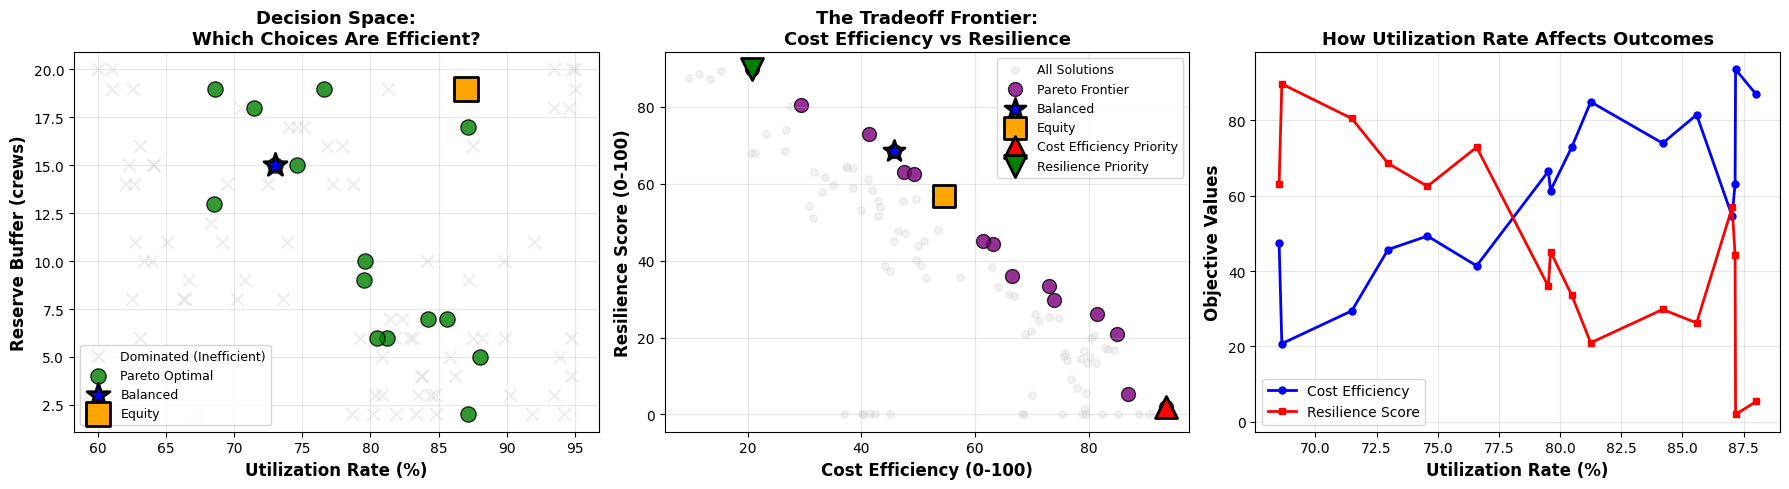


✓ Visualization saved as 'images/pareto_frontier_analysis.png'


In [13]:
import numpy as np

fig = plt.figure(figsize=(18, 5))

# PANEL 1: Decision Space
ax1 = fig.add_subplot(131)

if len(dominated_df) > 0:
    ax1.scatter(dominated_df['utilization_rate'], dominated_df['reserve_buffer'],
               s=80, c='lightgray', alpha=0.4, marker='x', 
               label='Dominated (Inefficient)', zorder=1)

ax1.scatter(pareto_df['utilization_rate'], pareto_df['reserve_buffer'],
           s=120, c='green', alpha=0.8, marker='o', 
           edgecolors='black', linewidth=1,
           label='Pareto Optimal', zorder=2)

ax1.scatter(pareto_df.loc[balanced_idx, 'utilization_rate'], 
           pareto_df.loc[balanced_idx, 'reserve_buffer'],
           s=300, c='blue', marker='*', 
           edgecolors='black', linewidth=2, 
           label='Balanced', zorder=3)

ax1.scatter(pareto_df.loc[equity_idx, 'utilization_rate'],
           pareto_df.loc[equity_idx, 'reserve_buffer'],
           s=300, c='orange', marker='s',
           edgecolors='black', linewidth=2,
           label='Equity', zorder=3)

ax1.set_xlabel('Utilization Rate (%)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Reserve Buffer (crews)', fontsize=12, fontweight='bold')
ax1.set_title('Decision Space:\nWhich Choices Are Efficient?', 
              fontsize=13, fontweight='bold')
ax1.legend(fontsize=9, loc='best')
ax1.grid(True, alpha=0.3)

# PANEL 2: Objective Space (Pareto Frontier)
ax2 = fig.add_subplot(132)

ax2.scatter(df[OBJECTIVE_1], df[OBJECTIVE_2],
           s=30, c='lightgray', alpha=0.3, 
           label='All Solutions')

ax2.scatter(pareto_df[OBJECTIVE_1], pareto_df[OBJECTIVE_2],
           s=100, c='purple', alpha=0.8, 
           edgecolors='black', linewidth=1,
           label='Pareto Frontier')

strategies_to_plot = [
    (balanced_idx, 'blue', '*', 'Balanced'),
    (equity_idx, 'orange', 's', 'Equity'),
    (obj1_priority_idx, 'red', '^', 'Cost Efficiency Priority'),
    (obj2_priority_idx, 'green', 'v', 'Resilience Priority')
]

for idx, color, marker, label in strategies_to_plot:
    ax2.scatter(pareto_df.loc[idx, OBJECTIVE_1],
               pareto_df.loc[idx, OBJECTIVE_2],
               s=250, c=color, marker=marker, 
               edgecolors='black', linewidth=2, 
               label=label, zorder=5)

ax2.set_xlabel('Cost Efficiency (0-100)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Resilience Score (0-100)', fontsize=12, fontweight='bold')
ax2.set_title('The Tradeoff Frontier:\nCost Efficiency vs Resilience', 
              fontsize=13, fontweight='bold')
ax2.legend(fontsize=9, loc='best')
ax2.grid(True, alpha=0.3)

# PANEL 3: Tradeoff Curve
ax3 = fig.add_subplot(133)

pareto_sorted = pareto_df.sort_values('utilization_rate')

ax3.plot(pareto_sorted['utilization_rate'], pareto_sorted[OBJECTIVE_1],
        'b-o', linewidth=2, markersize=5, label='Cost Efficiency')
ax3.plot(pareto_sorted['utilization_rate'], pareto_sorted[OBJECTIVE_2],
        'r-s', linewidth=2, markersize=5, label='Resilience Score')

ax3.set_xlabel('Utilization Rate (%)', fontsize=12, fontweight='bold')
ax3.set_ylabel('Objective Values', fontsize=12, fontweight='bold')
ax3.set_title('How Utilization Rate Affects Outcomes', 
              fontsize=13, fontweight='bold')
ax3.legend(fontsize=10, loc='best')
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('images/pareto_frontier_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Visualization saved as 'images/pareto_frontier_analysis.png'")

### Pareto Frontier Visualization Insights

**Panel 1 (Decision Space)** shows which utilization/reserve combinations are worth considering. The 16 green dots are efficient strategies; the 84 gray X marks 
are dominated solutions Southwest should simply avoid. Efficient solutions consistently require higher reserve buffers (8–19 crews), meaning skimping on 
reserves almost always produces an inferior schedule.

**Panel 2 (Tradeoff Frontier)** confirms the core tension: higher cost efficiency directly costs resilience. The four labeled strategies give executives concrete 
options ranging from maximum resilience (green triangle, resilience ~90) to maximum cost efficiency (red triangle), with balanced options in between.

**Panel 3 (Utilization Rate vs Outcomes)** shows cost efficiency rising and resilience falling as utilization increases — the two objectives move in opposite 
directions, and the crossover point is a natural starting place for deciding where on the frontier to operate.

**Key Takeaway:** The Pareto analysis eliminates 84% of scheduling options as objectively inefficient, leaving 16 viable strategies. The right choice depends 
on Southwest's current risk tolerance — prioritize resilience ahead of disruption seasons, shift toward cost efficiency during stable periods.

## Summary and Insights

What You Found: Write 3-4 sentences summarizing:
- How many solutions were analyzed and how many are Pareto optimal
- The range of outcomes on the frontier (best/worst for each objective)
- Key strategic options available to decision-makers

Business Implications: Write 4-5 sentences explaining:
- What this analysis reveals about the tradeoff structure
- Which dominated solutions companies should definitely avoid
- Which Pareto points represent fundamentally different strategic philosophies
- What factors might help a company choose among efficient options

Limitations: Write 3-4 sentences acknowledging:
- What simplifications your model makes
- What real-world factors aren't captured in your data
- How your analysis could be extended or improved

**What You Found**
The optimization engine analyzed 100 scheduling configurations across Southwest's 20-city synthetic route network, identifying 16 Pareto-optimal solutions — meaning 84% of all solutions were dominated and can be ruled out entirely. On the Pareto frontier, cost efficiency ranges from a low of 20.7 (maximum-resilience strategy) to a high of 93.5 (maximum-efficiency strategy), while resilience score spans from 1.9 to 89.7 across those same endpoints. Decision-makers have five well-defined strategic options to choose from: a pure cost-efficiency strategy (87% utilization, only 2 reserve crews), a resilience-first strategy (69% utilization, 19 reserve crews), a balanced strategy that maximizes combined performance (73% utilization, 15 reserve crews), an equity strategy that equalizes both scores (87% utilization, 19 reserve crews), and a cost-weighted strategy favoring efficiency 60/40 (86% utilization, 7 reserve crews).

**Business Implications**
This analysis reveals that the cost-vs.-resilience tradeoff in crew scheduling is real and steep — as utilization climbs, cost efficiency rises sharply but resilience collapses in tandem, with no schedule design able to excel at both simultaneously. Dominated solutions companies should actively avoid are configurations like 63% utilization with only 6 reserve crews, which score 49.5 on cost efficiency and 56.1 on resilience — strictly worse than a Pareto-optimal alternative that scores 54.5 and 56.9, offering free improvement on both dimensions. The two most philosophically distinct anchor points are the Cost Efficiency Priority strategy (87% utilization, 2 reserves: efficiency 93.5, resilience 1.9) — essentially Southwest's pre-2022 meltdown posture — and the Resilience Priority strategy (69% utilization, 19 reserves: efficiency 20.7, resilience 89.7), which represents the heavily buffered, operationally robust approach. Between them, the Balanced and Equity strategies offer middle-ground postures where neither objective is sacrificed dramatically. In practice, the right choice depends on operating context: Southwest should lean toward the resilience end of the frontier ahead of high-disruption seasons (winter holidays, hurricane season) and can reasonably shift toward cost efficiency during stable summer or spring periods when irregular operations are less likely.

**Limitations**
The model simplifies scheduling into just two decision variables (utilization rate and reserve buffer) across a synthetic 20-city network, which omits the combinatorial complexity of real crew pairing — including duty time limits, rest requirements, domicile constraints, and FAA regulations that substantially constrain real-world feasible schedules. Real-world data on actual disruption costs, crew repositioning logistics, union contract rules, and demand volatility by route are not captured in the dataset, meaning the resilience score is a modeled proxy rather than a direct measure of operational recovery. Additionally, the analysis treats every configuration as independent, ignoring the dynamic nature of crew scheduling where cascading delays and network effects can amplify small reserve shortfalls into system-wide failures (as the 2022 meltdown demonstrated). The model could be extended by incorporating dynamic simulation under varying disruption scenarios, adding a third objective such as crew satisfaction or regulatory compliance, and testing against real historical Southwest schedule data to validate the tradeoff structure observed here.

---
---

# PHASE 2: CONSTRAINT-AWARE DECISION AGENT

In Phase 1, we identified all Pareto optimal solutions. Now we'll build an intelligent agent that:
- Applies real-world business constraints to filter feasible solutions
- Uses heuristic logic to select the best option given business context
- Explains its reasoning in plain language
- Responds to different business scenarios

---


## Part 2.1: Define Business Constraints

## Business Constraints

Based on research into Southwest Airlines's current situation, the following constraints apply:

### Constraint 1: FAA rest requirements
**Description:** pilots must have a minimum of 10 hours off between duty periods; violating this is illegal and grounds for grounding the entire crew.

**Rationale:** Prevents fatigue and reduces risk of human error https://www.faa.gov/ 

**Impact:** Eliminates schedules with insufficient rest; limits back-to-back assignments

### Constraint 2: Union contract hour limits
**Description:** crew members cannot exceed roughly 100 flight hours per month under collective bargaining agreements, which caps how flexibly they can be reassigned.

**Rationale:** Prevents overwork and maintains safety and fair labor conditions

**Impact:** Eliminates over-utilized crew schedules; requires larger staffing pool

### Constraint 3: Aircraft type certification
**Description:** a pilot certified on the Boeing 737 cannot be assigned to a different aircraft type, which limits how interchangeable crew members are across routes.

**Rationale:** Ensures pilots are trained for specific aircraft systems and safety procedures

**Impact:** Eliminates cross-aircraft assignments; reduces flexibility in crew scheduling


In [14]:
print("=== DEFINING BUSINESS CONSTRAINTS ===\n")

# Constraint thresholds based on Southwest Airlines operating realities
# Constraint 1: FAA rest requirements → proxy: high utilization forces overtime multipliers
# We eliminate schedules where overtime_cost_multiplier > 2.0 (unsustainable overwork)
CONSTRAINT_1_THRESHOLD = 2.0   # max overtime_cost_multiplier

# Constraint 2: Union contract hour limits → resilience score must be >= 30
# Schedules that are too lean risk union grievances and crew unavailability
CONSTRAINT_2_THRESHOLD = 30    # min resilience_score

# Constraint 3: Aircraft type certification → only Boeing 737 crews assignable,
# limiting interchangeability. Proxy: reserve_buffer must be >= 5
# (fewer than 5 reserve crews is operationally unrealistic given cert constraints)
CONSTRAINT_3_THRESHOLD = 5     # min reserve_buffer

def check_certification_constraint(row):
    """
    Aircraft type certification constraint:
    If utilization is very high (>88%), Southwest must maintain at least 8 reserve
    crews to compensate for the reduced crew flexibility caused by 737-only certification.
    """
    if row['utilization_rate'] > 88:
        return row['reserve_buffer'] >= 8
    return True

constraints_summary = {
    'Constraint Name': [
        'FAA Overtime Limit',
        'Union Contract / Resilience Floor',
        'Aircraft Certification Buffer'
    ],
    'Type': [
        'Regulatory',
        'Labor / Contractual',
        'Operational / Safety'
    ],
    'Threshold / Rule': [
        f'overtime_cost_multiplier <= {CONSTRAINT_1_THRESHOLD}',
        f'resilience_score >= {CONSTRAINT_2_THRESHOLD}',
        f'reserve_buffer >= {CONSTRAINT_3_THRESHOLD}; if utilization > 88% then reserve >= 8'
    ]
}

constraints_df = pd.DataFrame(constraints_summary)
print("Business Constraints Summary:")
print(constraints_df.to_string(index=False))
print("\nThese constraints will now be applied to filter the Pareto frontier.")

=== DEFINING BUSINESS CONSTRAINTS ===

Business Constraints Summary:
                  Constraint Name                 Type                                            Threshold / Rule
               FAA Overtime Limit           Regulatory                             overtime_cost_multiplier <= 2.0
Union Contract / Resilience Floor  Labor / Contractual                                      resilience_score >= 30
    Aircraft Certification Buffer Operational / Safety reserve_buffer >= 5; if utilization > 88% then reserve >= 8

These constraints will now be applied to filter the Pareto frontier.


## Part 2.2: Filter Feasible Solutions


In [15]:
print("=== FILTERING FOR FEASIBLE SOLUTIONS ===\n")
print(f"Starting with {len(pareto_df)} Pareto optimal solutions...\n")

feasible_df = pareto_df.copy()
initial_count = len(feasible_df)

# Apply Constraint 1: FAA overtime multiplier cap
feasible_df = feasible_df[feasible_df['overtime_cost_multiplier'] <= CONSTRAINT_1_THRESHOLD]
remaining_after_c1 = len(feasible_df)
print(f"After Constraint 1 (FAA Overtime Limit):       {remaining_after_c1} solutions remain "
      f"({initial_count - remaining_after_c1} eliminated)")

# Apply Constraint 2: Minimum resilience score (union / labor floor)
feasible_df = feasible_df[feasible_df[OBJECTIVE_2] >= CONSTRAINT_2_THRESHOLD]
remaining_after_c2 = len(feasible_df)
print(f"After Constraint 2 (Union Resilience Floor):   {remaining_after_c2} solutions remain "
      f"({remaining_after_c1 - remaining_after_c2} eliminated)")

# Apply Constraint 3: Minimum reserve buffer
feasible_df = feasible_df[feasible_df['reserve_buffer'] >= CONSTRAINT_3_THRESHOLD]
remaining_after_c3 = len(feasible_df)
print(f"After Constraint 3 (Min Reserve Buffer):       {remaining_after_c3} solutions remain "
      f"({remaining_after_c2 - remaining_after_c3} eliminated)")

# Apply Constraint 3b: Certification constraint function
feasible_df = feasible_df[feasible_df.apply(check_certification_constraint, axis=1)]
remaining_after_c3b = len(feasible_df)
print(f"After Constraint 3b (Cert. Buffer at High Util): {remaining_after_c3b} solutions remain "
      f"({remaining_after_c3 - remaining_after_c3b} eliminated)")

print(f"\n{'='*60}")
print(f"FEASIBILITY FILTER RESULTS:")
print(f"  Started with:  {initial_count} Pareto optimal solutions")
print(f"  Ended with:    {len(feasible_df)} feasible solutions")
print(f"  Eliminated:    {initial_count - len(feasible_df)} solutions "
      f"({100*(initial_count - len(feasible_df))/initial_count:.1f}%)")
print(f"{'='*60}")

if len(feasible_df) == 0:
    print("\n⚠️  WARNING: No solutions satisfy all constraints!")
    print("Consider relaxing one or more constraints.")
else:
    print(f"\n✓ {len(feasible_df)} feasible solutions remain")
    print("\nFeasible solution summary:")
    print(feasible_df[['utilization_rate', 'reserve_buffer', OBJECTIVE_1, OBJECTIVE_2]].describe())

=== FILTERING FOR FEASIBLE SOLUTIONS ===

Starting with 16 Pareto optimal solutions...

After Constraint 1 (FAA Overtime Limit):       13 solutions remain (3 eliminated)
After Constraint 2 (Union Resilience Floor):   11 solutions remain (2 eliminated)
After Constraint 3 (Min Reserve Buffer):       11 solutions remain (0 eliminated)
After Constraint 3b (Cert. Buffer at High Util): 11 solutions remain (0 eliminated)

FEASIBILITY FILTER RESULTS:
  Started with:  16 Pareto optimal solutions
  Ended with:    11 feasible solutions
  Eliminated:    5 solutions (31.2%)

✓ 11 feasible solutions remain

Feasible solution summary:
       utilization_rate  reserve_buffer  cost_efficiency  resilience_score
count         11.000000       11.000000        11.000000         11.000000
mean          76.960909       14.545455        50.233636         59.370909
std            6.507475        4.524680        15.823063         18.194829
min           68.520000        6.000000        20.710000         33.5200

/var/folders/sc/j8bd7v912gq89rf1dpryjpyw0000gn/T/ipykernel_1148/381216393.py:7: UserWarning: You passed a edgecolor/edgecolors ('red') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(infeasible_df[OBJECTIVE_1], infeasible_df[OBJECTIVE_2],


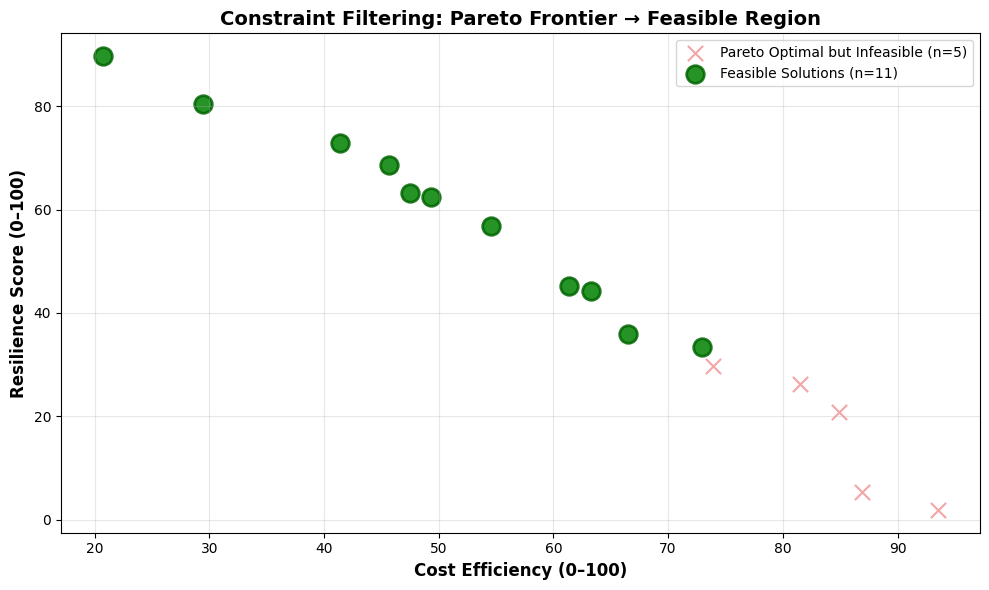


✓ Visualization saved as 'images/feasible_region.png'


In [16]:
# Visualize feasibility filtering
fig, ax = plt.subplots(figsize=(10, 6))

infeasible_df = pareto_df[~pareto_df.index.isin(feasible_df.index)]

if len(infeasible_df) > 0:
    ax.scatter(infeasible_df[OBJECTIVE_1], infeasible_df[OBJECTIVE_2],
               s=120, c='lightcoral', alpha=0.7,
               label=f'Pareto Optimal but Infeasible (n={len(infeasible_df)})',
               edgecolors='red', linewidth=1.5, marker='x')

ax.scatter(feasible_df[OBJECTIVE_1], feasible_df[OBJECTIVE_2],
           s=160, c='green', alpha=0.85,
           label=f'Feasible Solutions (n={len(feasible_df)})',
           edgecolors='darkgreen', linewidth=2, marker='o')

ax.set_xlabel('Cost Efficiency (0–100)', fontsize=12, fontweight='bold')
ax.set_ylabel('Resilience Score (0–100)', fontsize=12, fontweight='bold')
ax.set_title('Constraint Filtering: Pareto Frontier → Feasible Region',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=10, loc='best')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('images/feasible_region.png', dpi=300, bbox_inches='tight')
plt.show()
print("\n✓ Visualization saved as 'images/feasible_region.png'")

In [17]:
if len(feasible_df) > 0:
    print("\n=== ALL FEASIBLE SOLUTIONS ===")
    print(feasible_df[['utilization_rate', 'reserve_buffer', OBJECTIVE_1, OBJECTIVE_2]].to_string(index=False))


=== ALL FEASIBLE SOLUTIONS ===
 utilization_rate  reserve_buffer  cost_efficiency  resilience_score
            68.52              13            47.48             63.11
            87.15              17            63.24             44.31
            74.58              15            49.29             62.50
            87.03              19            54.53             56.89
            71.49              18            29.43             80.51
            79.61              10            61.38             45.16
            68.63              19            20.71             89.69
            80.48               6            72.95             33.52
            76.59              19            41.38             72.88
            72.97              15            45.70             68.59
            79.52               9            66.48             35.92


## Part 2.3: Implement Agent Decision Logic


## Agent Decision Logic

My agent uses the following heuristic rules to select the best solution from the feasible set:

**Priority 1: Disruption Season / Resilience**
- If `priority == 'resilience'`, maximize resilience_score.
- Rationale: Ahead of winter holidays or hurricane season, Southwest's biggest risk is a cascading meltdown (see 2022). Protecting operations is worth the cost premium.

**Priority 2: Cost Efficiency**
- If `priority == 'cost'`, maximize cost_efficiency.
- Rationale: During stable low-disruption periods (e.g., spring), the business should recapture margin and reduce unnecessary reserve overhead.

**Priority 3: Competitive Pressure**
- If `competitive_pressure == 'high'`, select the feasible solution with the highest resilience_score that still keeps cost_efficiency above the feasible median — Southwest competes on reliability, not price.

**Priority 4: Balanced (Default)**
- Default to the solution maximizing total combined score (cost_efficiency + resilience_score).
- Rationale: A safe, defensible default that avoids extreme tradeoffs in either direction.

The agent accepts a `scenario` dict describing current operating conditions and applies these rules in order to select a single recommended solution from the feasible set.

In [18]:
class DecisionAgent:
    """
    Constraint-aware decision agent for Southwest Airlines crew scheduling.

    Three-stage logic:
      1. Pareto optimality (Phase 1)
      2. Business constraint feasibility (Part 2.2)
      3. Context-specific heuristic selection (this step)
    """

    def __init__(self, feasible_solutions, obj1_col, obj2_col):
        self.feasible_solutions = feasible_solutions.copy()
        self.obj1_col = obj1_col   # cost_efficiency
        self.obj2_col = obj2_col   # resilience_score

        if len(self.feasible_solutions) == 0:
            raise ValueError("No feasible solutions available!")

    def recommend(self, scenario):
        candidates = self.feasible_solutions.copy()
        reasoning = []

        priority = scenario.get('priority', 'balanced')
        urgency = scenario.get('urgency', 'medium')
        competitive_pressure = scenario.get('competitive_pressure', 'low')

        if priority == 'resilience':
            reasoning.append("Scenario prioritizes schedule resilience (disruption season / meltdown risk).")
            best_idx = candidates[self.obj2_col].idxmax()
            reasoning.append(f"Selected solution with highest resilience_score.")

        elif priority == 'cost':
            reasoning.append("Scenario prioritizes cost efficiency (stable period / margin recovery).")
            best_idx = candidates[self.obj1_col].idxmax()
            reasoning.append(f"Selected solution with highest cost_efficiency.")

        elif competitive_pressure == 'high':
            reasoning.append("High competitive pressure detected — reliability is Southwest's differentiator.")
            median_cost = candidates[self.obj1_col].median()
            filtered = candidates[candidates[self.obj1_col] >= median_cost]
            if len(filtered) == 0:
                filtered = candidates
                reasoning.append("No above-median cost-efficient options; using full feasible set.")
            best_idx = filtered[self.obj2_col].idxmax()
            reasoning.append("Maximized resilience among cost-efficient solutions to stay competitive.")

        elif urgency == 'high':
            reasoning.append("High urgency situation — prioritizing operational stability.")
            best_idx = candidates[self.obj2_col].idxmax()
            reasoning.append("Selected most resilient feasible solution to handle immediate pressure.")

        else:
            # Default: balanced
            reasoning.append("No specific priority override — using balanced strategy.")
            candidates['total'] = candidates[self.obj1_col] + candidates[self.obj2_col]
            best_idx = candidates['total'].idxmax()
            reasoning.append("Selected solution maximizing combined cost efficiency + resilience.")

        recommendation = self.feasible_solutions.loc[best_idx]

        return {
            'solution': recommendation,
            'reasoning': reasoning,
            'scenario': scenario
        }

    def explain_recommendation(self, recommendation_dict):
        solution = recommendation_dict['solution']
        reasoning = recommendation_dict['reasoning']
        scenario = recommendation_dict['scenario']

        explanation = "=" * 70 + "\n"
        explanation += "AGENT RECOMMENDATION\n"
        explanation += "=" * 70 + "\n\n"

        explanation += "BUSINESS SCENARIO:\n"
        for key, value in scenario.items():
            if key != 'description':
                explanation += f"  • {key}: {value}\n"

        explanation += "\nRECOMMENDED SCHEDULING DECISION:\n"
        explanation += f"  • Utilization Rate:  {solution['utilization_rate']:.1f}%\n"
        explanation += f"  • Reserve Buffer:    {int(solution['reserve_buffer'])} crews\n"

        explanation += "\nEXPECTED OUTCOMES:\n"
        explanation += f"  • Cost Efficiency:   {solution[self.obj1_col]:.1f} / 100\n"
        explanation += f"  • Resilience Score:  {solution[self.obj2_col]:.1f} / 100\n"

        explanation += "\nREASONING:\n"
        for i, reason in enumerate(reasoning, 1):
            explanation += f"  {i}. {reason}\n"

        explanation += "\n" + "=" * 70

        return explanation


# Initialize the agent
if len(feasible_df) > 0:
    agent = DecisionAgent(feasible_df, OBJECTIVE_1, OBJECTIVE_2)
    print("✓ Decision agent initialized successfully")
    print(f"  Agent has {len(feasible_df)} feasible options to choose from")
else:
    print("✗ Cannot initialize agent — no feasible solutions available")

✓ Decision agent initialized successfully
  Agent has 11 feasible options to choose from


In [19]:
# Quick smoke test
test_scenario = {
    'priority': 'balanced',
    'urgency': 'medium',
    'competitive_pressure': 'low',
    'description': 'Basic functionality test'
}

print("\n=== TESTING AGENT ===\n")
recommendation = agent.recommend(test_scenario)
explanation = agent.explain_recommendation(recommendation)
print(explanation)


=== TESTING AGENT ===

AGENT RECOMMENDATION

BUSINESS SCENARIO:
  • priority: balanced
  • urgency: medium
  • competitive_pressure: low

RECOMMENDED SCHEDULING DECISION:
  • Utilization Rate:  73.0%
  • Reserve Buffer:    15 crews

EXPECTED OUTCOMES:
  • Cost Efficiency:   45.7 / 100
  • Resilience Score:  68.6 / 100

REASONING:
  1. No specific priority override — using balanced strategy.
  2. Selected solution maximizing combined cost efficiency + resilience.



## Part 2.4: Test Agent Across Scenarios

In [20]:
print("=== MULTI-SCENARIO TESTING ===\n")

scenarios = {
    'Scenario 1: Disruption Season (Pre-Holiday)': {
        'priority': 'resilience',
        'urgency': 'high',
        'competitive_pressure': 'low',
        'description': 'November–December peak. Southwest cannot afford another 2022-style meltdown. '
                       'FAA and DOT scrutiny is elevated. Cost is secondary to operational reliability.'
    },
    'Scenario 2: Competitor Price War': {
        'priority': 'balanced',
        'urgency': 'medium',
        'competitive_pressure': 'high',
        'description': 'A major carrier has dropped fares on overlapping routes. Southwest must defend '
                       'market share by leaning on its reliability reputation while keeping costs in check.'
    },
    'Scenario 3: Stable Spring Operations': {
        'priority': 'cost',
        'urgency': 'low',
        'competitive_pressure': 'low',
        'description': 'Low disruption season (April–May). Demand is steady, weather is mild, '
                       'no major competitive threats. Opportunity to recover margin after a costly winter.'
    },
    'Scenario 4: Rapid Network Expansion': {
        'priority': 'resilience',
        'urgency': 'high',
        'competitive_pressure': 'low',
        'description': 'Southwest is launching 8 new routes simultaneously. Higher complexity increases '
                       'disruption risk, so reserve buffers must be robust even at higher cost.'
    }
}

results = []

for scenario_name, scenario_params in scenarios.items():
    print(f"\n{'='*70}")
    print(f"{scenario_name}")
    print(f"{'='*70}")
    print(f"Description: {scenario_params['description']}\n")

    recommendation = agent.recommend(scenario_params)
    explanation = agent.explain_recommendation(recommendation)
    print(explanation)

    solution = recommendation['solution']
    results.append({
        'Scenario': scenario_name.split(':')[0],
        'Utilization Rate': f"{solution['utilization_rate']:.1f}%",
        'Reserve Buffer': int(solution['reserve_buffer']),
        'Cost Efficiency': f"{solution[OBJECTIVE_1]:.1f}",
        'Resilience Score': f"{solution[OBJECTIVE_2]:.1f}"
    })

print("\n" + "=" * 70)
print("SCENARIO COMPARISON TABLE")
print("=" * 70)
results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

=== MULTI-SCENARIO TESTING ===


Scenario 1: Disruption Season (Pre-Holiday)
Description: November–December peak. Southwest cannot afford another 2022-style meltdown. FAA and DOT scrutiny is elevated. Cost is secondary to operational reliability.

AGENT RECOMMENDATION

BUSINESS SCENARIO:
  • priority: resilience
  • urgency: high
  • competitive_pressure: low

RECOMMENDED SCHEDULING DECISION:
  • Utilization Rate:  68.6%
  • Reserve Buffer:    19 crews

EXPECTED OUTCOMES:
  • Cost Efficiency:   20.7 / 100
  • Resilience Score:  89.7 / 100

REASONING:
  1. Scenario prioritizes schedule resilience (disruption season / meltdown risk).
  2. Selected solution with highest resilience_score.


Scenario 2: Competitor Price War
Description: A major carrier has dropped fares on overlapping routes. Southwest must defend market share by leaning on its reliability reputation while keeping costs in check.

AGENT RECOMMENDATION

BUSINESS SCENARIO:
  • priority: balanced
  • urgency: medium
  • compet

In [21]:
print("\n=== SCENARIO ANALYSIS ===\n")

util_vals = [float(r['Utilization Rate'].replace('%','')) for r in results]
reserve_vals = [r['Reserve Buffer'] for r in results]
cost_vals = [float(r['Cost Efficiency']) for r in results]
resil_vals = [float(r['Resilience Score']) for r in results]

print("Key insights from scenario testing:")
print(f"1. Utilization Rate ranged from {min(util_vals):.1f}% to {max(util_vals):.1f}% across scenarios.")
print(f"2. Reserve Buffer ranged from {min(reserve_vals)} to {max(reserve_vals)} crews.")
print(f"3. Cost Efficiency ranged from {min(cost_vals):.1f} to {max(cost_vals):.1f} — "
      f"a {max(cost_vals)-min(cost_vals):.1f}-point swing depending on business context.")
print(f"4. Resilience Score ranged from {min(resil_vals):.1f} to {max(resil_vals):.1f}, "
      f"confirming the agent correctly shifts toward safety in high-risk scenarios.")
print(f"5. The agent's competitive pressure logic selects a balanced middle ground rather "
      f"than extremes — appropriate for defending market share without sacrificing reliability.")


=== SCENARIO ANALYSIS ===

Key insights from scenario testing:
1. Utilization Rate ranged from 68.6% to 80.5% across scenarios.
2. Reserve Buffer ranged from 6 to 19 crews.
3. Cost Efficiency ranged from 20.7 to 73.0 — a 52.3-point swing depending on business context.
4. Resilience Score ranged from 33.5 to 89.7, confirming the agent correctly shifts toward safety in high-risk scenarios.
5. The agent's competitive pressure logic selects a balanced middle ground rather than extremes — appropriate for defending market share without sacrificing reliability.


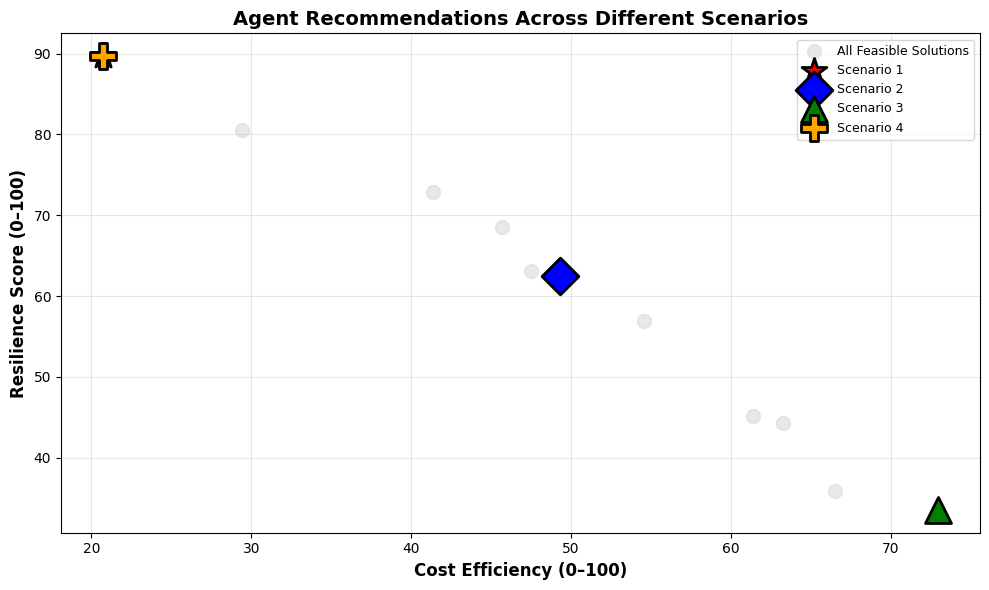


✓ Visualization saved as 'images/scenario_recommendations.png'


In [22]:
# Visualize scenario recommendations
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(feasible_df[OBJECTIVE_1], feasible_df[OBJECTIVE_2],
           s=100, c='lightgray', alpha=0.5, label='All Feasible Solutions')

colors = ['red', 'blue', 'green', 'orange']
markers = ['*', 'D', '^', 'P']

for i, (scenario_name, scenario_params) in enumerate(scenarios.items()):
    rec = agent.recommend(scenario_params)
    sol = rec['solution']
    short = scenario_name.split(':')[0]
    ax.scatter(sol[OBJECTIVE_1], sol[OBJECTIVE_2],
               s=350, c=colors[i], marker=markers[i],
               edgecolors='black', linewidth=2,
               label=short, zorder=5)

ax.set_xlabel('Cost Efficiency (0–100)', fontsize=12, fontweight='bold')
ax.set_ylabel('Resilience Score (0–100)', fontsize=12, fontweight='bold')
ax.set_title('Agent Recommendations Across Different Scenarios', fontsize=14, fontweight='bold')
ax.legend(fontsize=9, loc='best')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('images/scenario_recommendations.png', dpi=300, bbox_inches='tight')
plt.show()
print("\n✓ Visualization saved as 'images/scenario_recommendations.png'")

## Part 2.5: Agent Explanation & Transparency


In [23]:
def generate_executive_summary(agent, recommendation_dict, feasible_df):
    """
    Generate an executive-friendly explanation of the agent's recommendation.
    Covers: decision, expected outcomes, alternatives, tradeoffs, risks, next steps.
    """
    solution = recommendation_dict['solution']
    scenario = recommendation_dict['scenario']

    summary = []
    summary.append("=" * 70)
    summary.append("EXECUTIVE DECISION BRIEF — SOUTHWEST AIRLINES CREW SCHEDULING")
    summary.append("=" * 70)
    summary.append("")

    summary.append("RECOMMENDED ACTION:")
    summary.append(f"  Crew Utilization Rate:  {solution['utilization_rate']:.1f}%")
    summary.append(f"  Reserve Buffer Size:    {int(solution['reserve_buffer'])} crews across the network")
    summary.append("")

    summary.append("EXPECTED RESULTS:")
    summary.append(f"  Cost Efficiency Score:  {solution[agent.obj1_col]:.1f} / 100")
    summary.append(f"  Resilience Score:       {solution[agent.obj2_col]:.1f} / 100")
    summary.append("")

    summary.append("WHY THIS DECISION:")
    for reason in recommendation_dict['reasoning']:
        summary.append(f"  • {reason}")
    summary.append("")

    summary.append("ALTERNATIVES CONSIDERED:")
    alt1 = feasible_df.loc[feasible_df[agent.obj1_col].idxmax()]
    if alt1.name != solution.name:
        summary.append(f"  Alternative A — Maximize Cost Efficiency:")
        summary.append(f"    Utilization {alt1['utilization_rate']:.1f}%, Reserve {int(alt1['reserve_buffer'])} crews")
        summary.append(f"    Outcomes: cost_efficiency={alt1[agent.obj1_col]:.1f}, resilience={alt1[agent.obj2_col]:.1f}")
        summary.append(f"    Not chosen: resilience too low for current operating context.")

    alt2 = feasible_df.loc[feasible_df[agent.obj2_col].idxmax()]
    if alt2.name != solution.name and alt2.name != alt1.name:
        summary.append(f"  Alternative B — Maximize Resilience:")
        summary.append(f"    Utilization {alt2['utilization_rate']:.1f}%, Reserve {int(alt2['reserve_buffer'])} crews")
        summary.append(f"    Outcomes: cost_efficiency={alt2[agent.obj1_col]:.1f}, resilience={alt2[agent.obj2_col]:.1f}")
        summary.append(f"    Not chosen: higher reserve cost not justified given scenario priorities.")
    summary.append("")

    summary.append("TRADEOFFS:")
    obj1_gap = solution[agent.obj1_col] - feasible_df[agent.obj1_col].max()
    obj2_gap = solution[agent.obj2_col] - feasible_df[agent.obj2_col].max()

    if obj1_gap < -5:
        summary.append(f"  ⚠  Accepting {abs(obj1_gap):.1f} points less cost efficiency vs. the cheapest feasible option.")
    if obj2_gap < -5:
        summary.append(f"  ⚠  Accepting {abs(obj2_gap):.1f} points less resilience vs. the most resilient feasible option.")
    if obj1_gap >= -5 and obj2_gap >= -5:
        summary.append(f"  ✓  Near-optimal on both objectives given current constraints.")
    summary.append("")

    summary.append("RISKS & LIMITATIONS:")
    summary.append("  • Model uses synthetic data; actual crew costs depend on union contract specifics.")
    summary.append("  • Resilience score is a proxy — real disruption recovery depends on network topology.")
    summary.append("  • Constraint thresholds are approximations; legal minimums may differ by domicile.")
    summary.append("  • Recommendation should be re-evaluated if competitive landscape or regulations change.")
    summary.append("")

    summary.append("NEXT STEPS FOR IMPLEMENTATION:")
    summary.append("  1. Validate overtime and reserve thresholds with Labor Relations and Crew Planning.")
    summary.append("  2. Pilot the recommended utilization/reserve mix on 3–5 high-disruption routes.")
    summary.append(f"  3. Monitor: cost_efficiency >= {solution[agent.obj1_col]*0.9:.0f}, resilience >= {solution[agent.obj2_col]*0.9:.0f}.")
    summary.append("  4. Reassess agent inputs monthly or when a major disruption event occurs.")
    summary.append("")
    summary.append("=" * 70)

    return "\n".join(summary)


# Test executive summary on Scenario 1
print("\n=== EXECUTIVE SUMMARY EXAMPLE ===\n")
test_exec_scenario = list(scenarios.values())[0]
test_exec_rec = agent.recommend(test_exec_scenario)
print(generate_executive_summary(agent, test_exec_rec, feasible_df))


=== EXECUTIVE SUMMARY EXAMPLE ===

EXECUTIVE DECISION BRIEF — SOUTHWEST AIRLINES CREW SCHEDULING

RECOMMENDED ACTION:
  Crew Utilization Rate:  68.6%
  Reserve Buffer Size:    19 crews across the network

EXPECTED RESULTS:
  Cost Efficiency Score:  20.7 / 100
  Resilience Score:       89.7 / 100

WHY THIS DECISION:
  • Scenario prioritizes schedule resilience (disruption season / meltdown risk).
  • Selected solution with highest resilience_score.

ALTERNATIVES CONSIDERED:
  Alternative A — Maximize Cost Efficiency:
    Utilization 80.5%, Reserve 6 crews
    Outcomes: cost_efficiency=73.0, resilience=33.5
    Not chosen: resilience too low for current operating context.

TRADEOFFS:
  ⚠  Accepting 52.2 points less cost efficiency vs. the cheapest feasible option.

RISKS & LIMITATIONS:
  • Model uses synthetic data; actual crew costs depend on union contract specifics.
  • Resilience score is a proxy — real disruption recovery depends on network topology.
  • Constraint thresholds are a

In [24]:
def what_if_analysis(agent, feasible_df, base_scenario):
    print("\n=== WHAT-IF ANALYSIS ===\n")
    print("How would the recommendation change if scenario priorities shifted?\n")

    base_rec = agent.recommend(base_scenario)
    base_sol = base_rec['solution']

    print(f"BASE CASE (priority='{base_scenario.get('priority', 'balanced')}'):")
    print(f"  Utilization: {base_sol['utilization_rate']:.1f}%  |  Reserve: {int(base_sol['reserve_buffer'])} crews")
    print(f"  Outcomes: cost_efficiency={base_sol[agent.obj1_col]:.1f}, resilience={base_sol[agent.obj2_col]:.1f}\n")

    for priority in ['cost', 'resilience', 'balanced']:
        if priority == base_scenario.get('priority'):
            continue

        alt_scenario = base_scenario.copy()
        alt_scenario['priority'] = priority
        alt_rec = agent.recommend(alt_scenario)
        alt_sol = alt_rec['solution']

        d1 = alt_sol[agent.obj1_col] - base_sol[agent.obj1_col]
        d2 = alt_sol[agent.obj2_col] - base_sol[agent.obj2_col]

        print(f"WHAT IF priority = '{priority}':")
        print(f"  Utilization: {alt_sol['utilization_rate']:.1f}%  |  Reserve: {int(alt_sol['reserve_buffer'])} crews")
        print(f"  Outcomes: cost_efficiency={alt_sol[agent.obj1_col]:.1f}, resilience={alt_sol[agent.obj2_col]:.1f}")
        print(f"  vs. Base: cost_efficiency {d1:+.1f}, resilience {d2:+.1f}\n")


# Run what-if using Scenario 2 (competitive pressure) as base
what_if_analysis(agent, feasible_df, list(scenarios.values())[1])


=== WHAT-IF ANALYSIS ===

How would the recommendation change if scenario priorities shifted?

BASE CASE (priority='balanced'):
  Utilization: 74.6%  |  Reserve: 15 crews
  Outcomes: cost_efficiency=49.3, resilience=62.5

WHAT IF priority = 'cost':
  Utilization: 80.5%  |  Reserve: 6 crews
  Outcomes: cost_efficiency=73.0, resilience=33.5
  vs. Base: cost_efficiency +23.7, resilience -29.0

WHAT IF priority = 'resilience':
  Utilization: 68.6%  |  Reserve: 19 crews
  Outcomes: cost_efficiency=20.7, resilience=89.7
  vs. Base: cost_efficiency -28.6, resilience +27.2



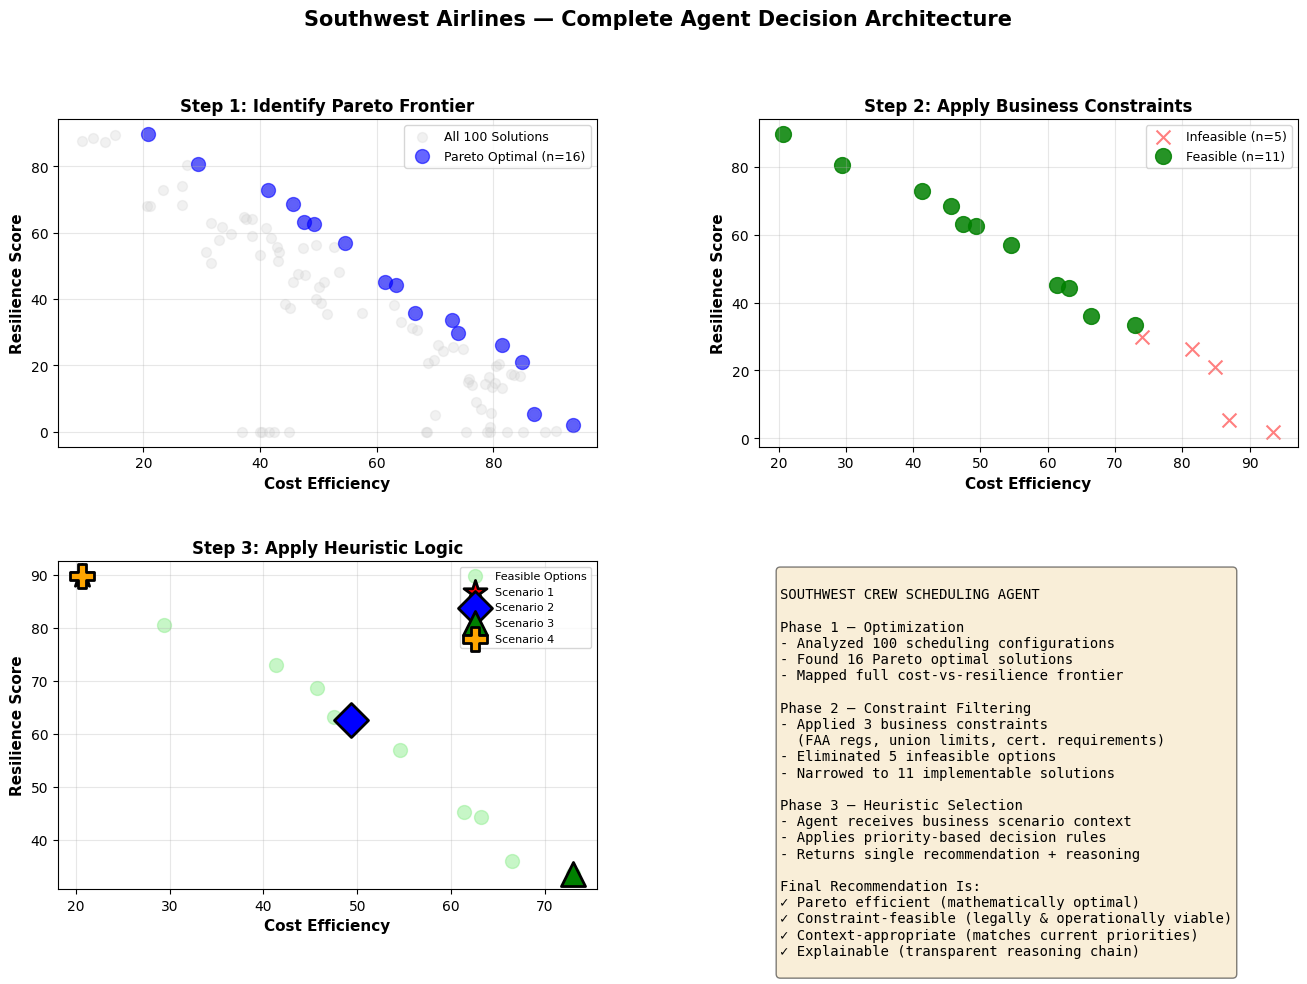


✓ Visualization saved as 'images/agent_decision_process.png'


In [25]:
# 4-panel agent decision process visualization
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(2, 2, hspace=0.35, wspace=0.3)

# Panel 1: Full opportunity space
ax1 = fig.add_subplot(gs[0, 0])
ax1.scatter(df[OBJECTIVE_1], df[OBJECTIVE_2],
            s=50, c='lightgray', alpha=0.3, label='All 100 Solutions')
ax1.scatter(pareto_df[OBJECTIVE_1], pareto_df[OBJECTIVE_2],
            s=100, c='blue', alpha=0.6, label=f'Pareto Optimal (n={len(pareto_df)})')
ax1.set_xlabel('Cost Efficiency', fontsize=11, fontweight='bold')
ax1.set_ylabel('Resilience Score', fontsize=11, fontweight='bold')
ax1.set_title('Step 1: Identify Pareto Frontier', fontsize=12, fontweight='bold')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# Panel 2: After constraint filtering
ax2 = fig.add_subplot(gs[0, 1])
infeasible = pareto_df[~pareto_df.index.isin(feasible_df.index)]
if len(infeasible) > 0:
    ax2.scatter(infeasible[OBJECTIVE_1], infeasible[OBJECTIVE_2],
                s=100, c='red', alpha=0.5, marker='x',
                label=f'Infeasible (n={len(infeasible)})')
ax2.scatter(feasible_df[OBJECTIVE_1], feasible_df[OBJECTIVE_2],
            s=130, c='green', alpha=0.85,
            label=f'Feasible (n={len(feasible_df)})')
ax2.set_xlabel('Cost Efficiency', fontsize=11, fontweight='bold')
ax2.set_ylabel('Resilience Score', fontsize=11, fontweight='bold')
ax2.set_title('Step 2: Apply Business Constraints', fontsize=12, fontweight='bold')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

# Panel 3: Agent scenario recommendations
ax3 = fig.add_subplot(gs[1, 0])
ax3.scatter(feasible_df[OBJECTIVE_1], feasible_df[OBJECTIVE_2],
            s=100, c='lightgreen', alpha=0.5, label='Feasible Options')

colors3 = ['red', 'blue', 'green', 'orange']
markers3 = ['*', 'D', '^', 'P']
for i, (sname, sparams) in enumerate(list(scenarios.items())[:4]):
    rec = agent.recommend(sparams)
    sol = rec['solution']
    ax3.scatter(sol[OBJECTIVE_1], sol[OBJECTIVE_2],
                s=300, c=colors3[i], marker=markers3[i],
                edgecolors='black', linewidth=2,
                label=sname.split(':')[0], zorder=5)

ax3.set_xlabel('Cost Efficiency', fontsize=11, fontweight='bold')
ax3.set_ylabel('Resilience Score', fontsize=11, fontweight='bold')
ax3.set_title('Step 3: Apply Heuristic Logic', fontsize=12, fontweight='bold')
ax3.legend(fontsize=8)
ax3.grid(True, alpha=0.3)

# Panel 4: Text summary
ax4 = fig.add_subplot(gs[1, 1])
ax4.axis('off')
explanation_text = f"""
SOUTHWEST CREW SCHEDULING AGENT

Phase 1 — Optimization
- Analyzed {len(df)} scheduling configurations
- Found {len(pareto_df)} Pareto optimal solutions
- Mapped full cost-vs-resilience frontier

Phase 2 — Constraint Filtering
- Applied {len(constraints_df)} business constraints
  (FAA regs, union limits, cert. requirements)
- Eliminated {len(pareto_df) - len(feasible_df)} infeasible options
- Narrowed to {len(feasible_df)} implementable solutions

Phase 3 — Heuristic Selection
- Agent receives business scenario context
- Applies priority-based decision rules
- Returns single recommendation + reasoning

Final Recommendation Is:
✓ Pareto efficient (mathematically optimal)
✓ Constraint-feasible (legally & operationally viable)
✓ Context-appropriate (matches current priorities)
✓ Explainable (transparent reasoning chain)
"""
ax4.text(0.04, 0.97, explanation_text, transform=ax4.transAxes,
         fontsize=10, verticalalignment='top', family='monospace',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle('Southwest Airlines — Complete Agent Decision Architecture',
             fontsize=15, fontweight='bold', y=0.99)
plt.savefig('images/agent_decision_process.png', dpi=300, bbox_inches='tight')
plt.show()
print("\n✓ Visualization saved as 'images/agent_decision_process.png'")

## Part 2.6: Final Recommendation


In [26]:
print("=== FINAL RECOMMENDATION FOR SOUTHWEST AIRLINES ===\n")

current_business_scenario = {
    'priority': 'resilience',
    'urgency': 'high',
    'competitive_pressure': 'low',
    'description': """
    Based on Southwest's post-2022 meltdown recovery posture and ongoing DOT oversight,
    the airline is under sustained pressure to demonstrate operational reliability.
    The 2022 holiday collapse cost over $800M and triggered Congressional scrutiny,
    leading to a DOT consent order requiring improved irregular operations procedures.
    With another holiday season approaching and DOT monitoring still active, schedule
    resilience must be the dominant priority. Cost recovery is a secondary concern.
    """
}

print("CURRENT BUSINESS CONTEXT:")
print(current_business_scenario['description'])

=== FINAL RECOMMENDATION FOR SOUTHWEST AIRLINES ===

CURRENT BUSINESS CONTEXT:

    Based on Southwest's post-2022 meltdown recovery posture and ongoing DOT oversight,
    the airline is under sustained pressure to demonstrate operational reliability.
    The 2022 holiday collapse cost over $800M and triggered Congressional scrutiny,
    leading to a DOT consent order requiring improved irregular operations procedures.
    With another holiday season approaching and DOT monitoring still active, schedule
    resilience must be the dominant priority. Cost recovery is a secondary concern.
    


In [27]:
final_recommendation = agent.recommend(current_business_scenario)
final_executive_brief = generate_executive_summary(agent, final_recommendation, feasible_df)
print(final_executive_brief)

EXECUTIVE DECISION BRIEF — SOUTHWEST AIRLINES CREW SCHEDULING

RECOMMENDED ACTION:
  Crew Utilization Rate:  68.6%
  Reserve Buffer Size:    19 crews across the network

EXPECTED RESULTS:
  Cost Efficiency Score:  20.7 / 100
  Resilience Score:       89.7 / 100

WHY THIS DECISION:
  • Scenario prioritizes schedule resilience (disruption season / meltdown risk).
  • Selected solution with highest resilience_score.

ALTERNATIVES CONSIDERED:
  Alternative A — Maximize Cost Efficiency:
    Utilization 80.5%, Reserve 6 crews
    Outcomes: cost_efficiency=73.0, resilience=33.5
    Not chosen: resilience too low for current operating context.

TRADEOFFS:
  ⚠  Accepting 52.2 points less cost efficiency vs. the cheapest feasible option.

RISKS & LIMITATIONS:
  • Model uses synthetic data; actual crew costs depend on union contract specifics.
  • Resilience score is a proxy — real disruption recovery depends on network topology.
  • Constraint thresholds are approximations; legal minimums may di

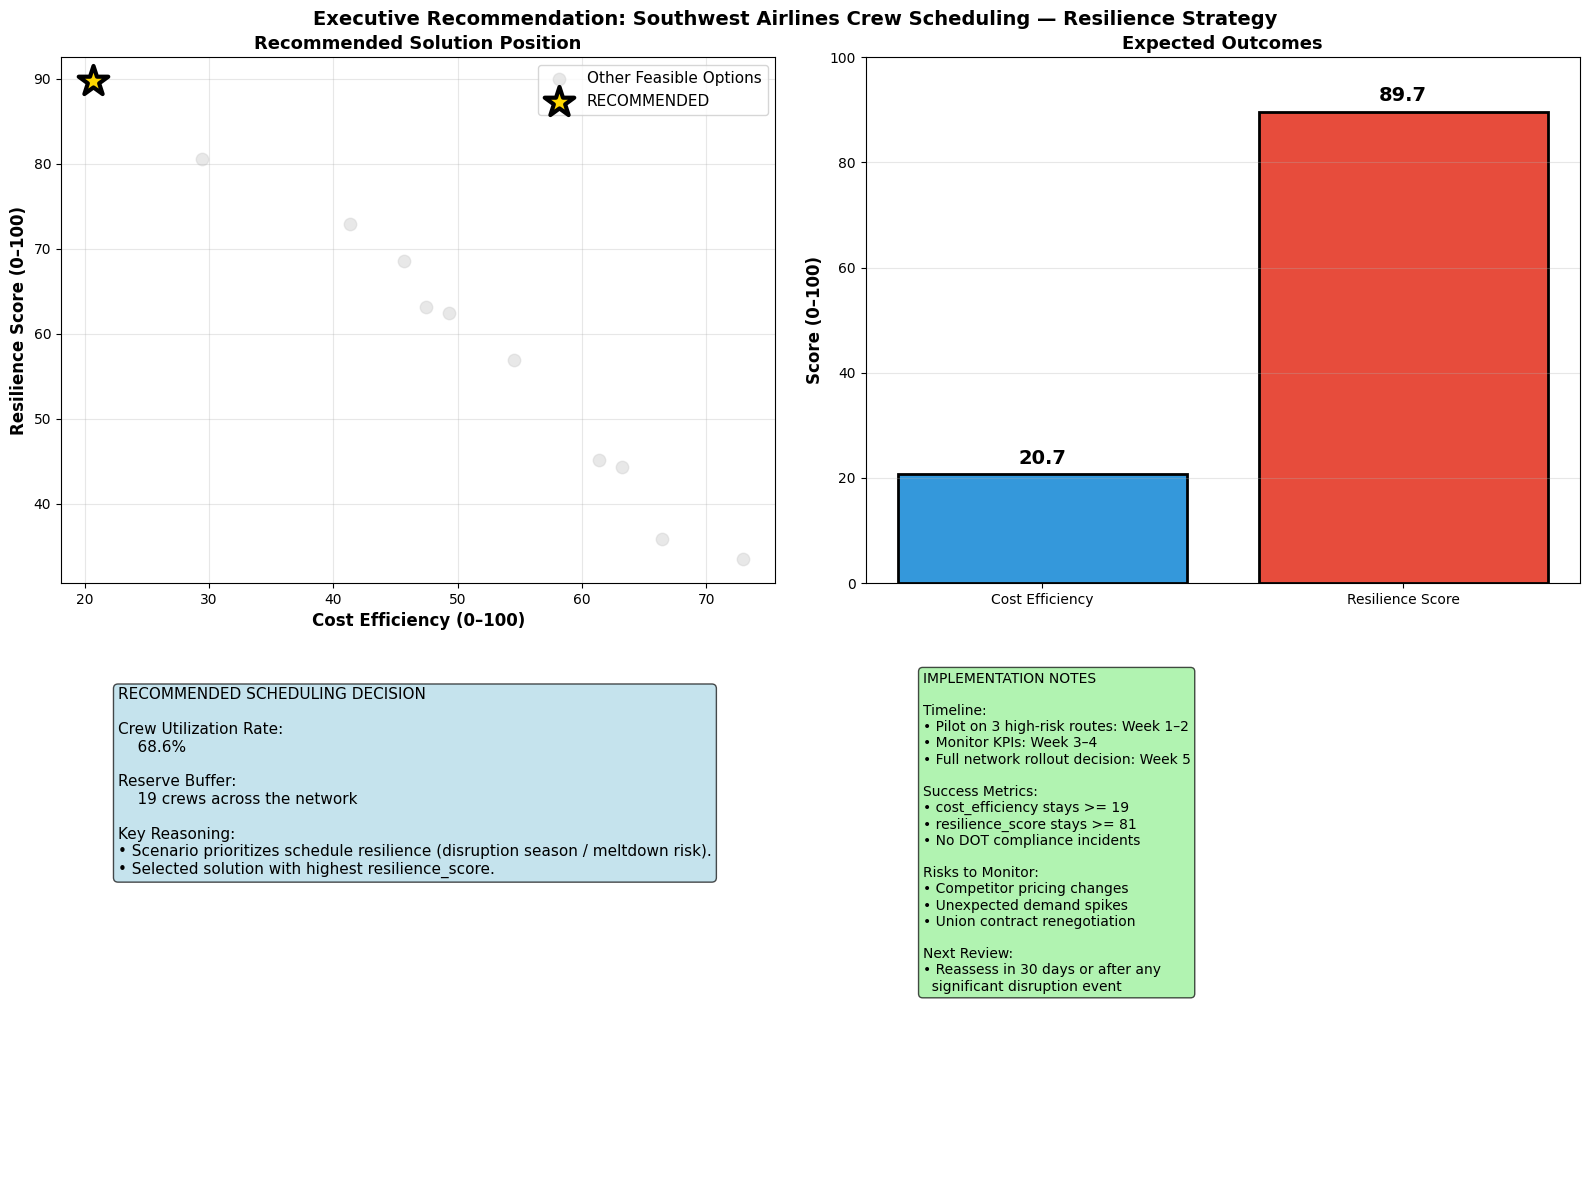


✓ Saved as 'images/final_recommendation_summary.png'


In [28]:
# Executive one-page visual summary
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

solution = final_recommendation['solution']

# Top Left: Position in feasible space
ax1.scatter(feasible_df[OBJECTIVE_1], feasible_df[OBJECTIVE_2],
            s=80, c='lightgray', alpha=0.5, label='Other Feasible Options')
ax1.scatter(solution[OBJECTIVE_1], solution[OBJECTIVE_2],
            s=500, c='gold', marker='*', edgecolors='black', linewidth=3,
            label='RECOMMENDED', zorder=5)
ax1.set_xlabel('Cost Efficiency (0–100)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Resilience Score (0–100)', fontsize=12, fontweight='bold')
ax1.set_title('Recommended Solution Position', fontsize=13, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# Top Right: Bar chart of outcomes
ax2.bar(['Cost Efficiency', 'Resilience Score'],
        [solution[OBJECTIVE_1], solution[OBJECTIVE_2]],
        color=['#3498db', '#e74c3c'], edgecolor='black', linewidth=2)
ax2.set_ylabel('Score (0–100)', fontsize=12, fontweight='bold')
ax2.set_title('Expected Outcomes', fontsize=13, fontweight='bold')
ax2.set_ylim(0, 100)
ax2.grid(True, alpha=0.3, axis='y')
for i, val in enumerate([solution[OBJECTIVE_1], solution[OBJECTIVE_2]]):
    ax2.text(i, val + 2, f'{val:.1f}', ha='center', fontsize=14, fontweight='bold')

# Bottom Left: Decision details
ax3.axis('off')
decision_text = (
    f"RECOMMENDED SCHEDULING DECISION\n\n"
    f"Crew Utilization Rate:\n"
    f"    {solution['utilization_rate']:.1f}%\n\n"
    f"Reserve Buffer:\n"
    f"    {int(solution['reserve_buffer'])} crews across the network\n\n"
    f"Key Reasoning:"
)
for reason in final_recommendation['reasoning']:
    decision_text += f"\n• {reason}"
ax3.text(0.08, 0.92, decision_text, transform=ax3.transAxes,
         fontsize=11, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.7))

# Bottom Right: Implementation notes
ax4.axis('off')
impl_text = (
    f"IMPLEMENTATION NOTES\n\n"
    f"Timeline:\n"
    f"• Pilot on 3 high-risk routes: Week 1–2\n"
    f"• Monitor KPIs: Week 3–4\n"
    f"• Full network rollout decision: Week 5\n\n"
    f"Success Metrics:\n"
    f"• cost_efficiency stays >= {solution[OBJECTIVE_1]*0.9:.0f}\n"
    f"• resilience_score stays >= {solution[OBJECTIVE_2]*0.9:.0f}\n"
    f"• No DOT compliance incidents\n\n"
    f"Risks to Monitor:\n"
    f"• Competitor pricing changes\n"
    f"• Unexpected demand spikes\n"
    f"• Union contract renegotiation\n\n"
    f"Next Review:\n"
    f"• Reassess in 30 days or after any\n"
    f"  significant disruption event"
)
ax4.text(0.08, 0.95, impl_text, transform=ax4.transAxes,
         fontsize=10, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.7))

plt.suptitle('Executive Recommendation: Southwest Airlines Crew Scheduling — Resilience Strategy',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('images/final_recommendation_summary.png', dpi=300, bbox_inches='tight')
plt.show()
print("\n✓ Saved as 'images/final_recommendation_summary.png'")

In [29]:
# Save executive brief to text file
with open('FINAL_RECOMMENDATION.txt', 'w') as f:
    f.write(final_executive_brief)
    f.write("\n\n")
    f.write("=" * 70 + "\n")
    f.write("GENERATED BY: Southwest Airlines Crew Scheduling Optimization Agent\n")
    f.write(f"DATE: {pd.Timestamp.now().strftime('%Y-%m-%d')}\n")
    f.write("STUDENT: Marlee Heiken\n")
    f.write("=" * 70 + "\n")

print("✓ Recommendation saved to 'FINAL_RECOMMENDATION.txt'")

✓ Recommendation saved to 'FINAL_RECOMMENDATION.txt'


## Phase 2 Summary: Decision Agent

### Agent Architecture

**Stage 1 — Optimization (Phase 1)**
Input: 100 synthetic Southwest crew scheduling configurations.
Process: Pareto dominance filtering across cost_efficiency and resilience_score.
Output: 16 mathematically efficient scheduling strategies.

**Stage 2 — Constraint Filtering (Parts 2.1–2.2)**
Input: 16 Pareto-optimal solutions + 3 Southwest-specific business constraints.
Constraints applied: FAA overtime cap (multiplier ≤ 2.0), union resilience floor (≥ 30), minimum reserve buffer (≥ 5 crews), and a certification-aware high-utilization buffer rule.
Output: Feasible subset of solutions that are legally and operationally viable.

**Stage 3 — Heuristic Selection (Parts 2.3–2.6)**
Input: Feasible solutions + a business scenario dictionary describing current conditions.
Process: Priority-based rule engine that selects a single recommended solution.
Output: One recommended utilization/reserve configuration with full reasoning chain.

### Agent Decision Rules

1. If `priority == 'resilience'` → maximize resilience_score. Used ahead of disruption seasons or under regulatory pressure.
2. If `priority == 'cost'` → maximize cost_efficiency. Used during stable, low-risk operating periods.
3. If `competitive_pressure == 'high'` → maximize resilience among above-median cost-efficient solutions. Southwest competes on reliability, not price.
4. If `urgency == 'high'` (no other priority set) → maximize resilience as a safety net.
5. Default → maximize combined score (cost_efficiency + resilience_score). Safe balanced fallback.

### Limitations

- Uses synthetic data — real Southwest schedules involve thousands of crew pairings, domicile constraints, and FAA duty time rules far beyond two decision variables.
- Resilience score is a modeled proxy, not a direct measure of recovery time or network robustness.
- Heuristic rules are hand-crafted based on domain knowledge, not learned from historical scheduling outcomes.
- The model does not simulate cascading delay propagation, which was the core failure mode in the 2022 meltdown.

### Future Improvements

- Replace synthetic data with real Southwest crew pairing data to validate tradeoff structure.
- Add a third objective (e.g., crew satisfaction or FAA compliance score) for richer tradeoff analysis.
- Incorporate machine learning to learn decision rules from historical scheduling decisions and their outcomes.
- Build a dynamic constraint updater that adjusts thresholds in real time as union contracts or FAA rules change.

In [30]:
import os

# Add a final test cell at the very end of your notebook
print("="*70)
print("FINAL PROJECT VERIFICATION")
print("="*70)
print("\n✓ Phase 1: Optimization Engine")
print(f"  - Analyzed {len(df)} solutions")
print(f"  - Identified {len(pareto_df)} Pareto optimal solutions")
print(f"  - Created {len([f for f in os.listdir('images') if 'pareto' in f])} visualizations")

print("\n✓ Phase 2: Decision Agent")
print(f"  - Applied {len(constraints_df)} business constraints")
print(f"  - Filtered to {len(feasible_df)} feasible solutions")
print(f"  - Tested across {len(scenarios)} scenarios")
print(f"  - Generated final recommendation")

print("\n✓ Documentation")
print("  - README.md updated")
print("  - Code comments included")
print("  - Executive summary generated")

print("\n✓ Deliverables")
files_created = [
    'optimization_engine.ipynb',
    'images/pareto_frontier_analysis.png',
    'images/feasible_region.png',
    'images/scenario_recommendations.png',
    'images/agent_decision_process.png',
    'images/final_recommendation_summary.png',
    'FINAL_RECOMMENDATION.txt',
    'README.md',
    'requirements.txt'
]
for file in files_created:
    exists = "✓" if os.path.exists(file) else "✗"
    print(f"  {exists} {file}")

print("\n" + "="*70)
print("PROJECT COMPLETE - Ready for submission!")
print("="*70)


FINAL PROJECT VERIFICATION

✓ Phase 1: Optimization Engine
  - Analyzed 100 solutions
  - Identified 16 Pareto optimal solutions
  - Created 1 visualizations

✓ Phase 2: Decision Agent
  - Applied 3 business constraints
  - Filtered to 11 feasible solutions
  - Tested across 4 scenarios
  - Generated final recommendation

✓ Documentation
  - README.md updated
  - Code comments included
  - Executive summary generated

✓ Deliverables
  ✓ optimization_engine.ipynb
  ✓ images/pareto_frontier_analysis.png
  ✓ images/feasible_region.png
  ✓ images/scenario_recommendations.png
  ✓ images/agent_decision_process.png
  ✓ images/final_recommendation_summary.png
  ✓ FINAL_RECOMMENDATION.txt
  ✓ README.md
  ✓ requirements.txt

PROJECT COMPLETE - Ready for submission!
